In [1]:
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
def img2vector(filename):
    returnVect = np.zeros((1, 1024))

    with open(filename, 'r') as fr:
        for i in range(32):
            lineStr = fr.readline().strip()

            for j in range(32):
                returnVect[0, 32 * i + j] = int(lineStr[j])

    return returnVect

In [3]:
test_vector = img2vector('trainingDigits/0_0.txt')

print("Shape:", test_vector.shape)
print(test_vector)

Shape: (1, 1024)
[[0. 0. 0. ... 0. 0. 0.]]


In [4]:
trainingFileList = os.listdir('trainingDigits')

m = len(trainingFileList)

trainingMat = np.zeros((m, 1024))
hwLabels = []

for i in range(m):
    fileNameStr = trainingFileList[i]

    fileStr = fileNameStr.split('.')[0]
    classNumStr = int(fileStr.split('_')[0])

    hwLabels.append(classNumStr)

    trainingMat[i, :] = img2vector(
        'trainingDigits/' + fileNameStr
    )

print("Training samples:", m)
print("Training data shape:", trainingMat.shape)

Training samples: 1934
Training data shape: (1934, 1024)


In [5]:
trainingFileList = os.listdir('trainingDigits')

m = len(trainingFileList)

trainingMat = np.zeros((m, 1024))
hwLabels = []

for i in range(m):
    fileNameStr = trainingFileList[i]

    fileStr = fileNameStr.split('.')[0]
    classNumStr = int(fileStr.split('_')[0])

    hwLabels.append(classNumStr)

    trainingMat[i, :] = img2vector(
        'trainingDigits/' + fileNameStr
    )

print("Training samples:", m)
print("Training data shape:", trainingMat.shape)

Training samples: 1934
Training data shape: (1934, 1024)


In [6]:
model = KNeighborsClassifier(
    n_neighbors=3,
    metric='minkowski',
    p=2
)

model.fit(trainingMat, hwLabels)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
testFileList = os.listdir('testDigits')

testMat = np.zeros((len(testFileList), 1024))
testLabels = []

for i in range(len(testFileList)):
    fileNameStr = testFileList[i]

    fileStr = fileNameStr.split('.')[0]
    classNumStr = int(fileStr.split('_')[0])

    testLabels.append(classNumStr)

    testMat[i, :] = img2vector(
        'testDigits/' + fileNameStr
    )

print("Test samples:", len(testFileList))
print("Test data shape:", testMat.shape)

Test samples: 946
Test data shape: (946, 1024)


In [8]:
y_pred = model.predict(testMat)

print("Predicted digits:")
print(y_pred)

Predicted digits:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 7 1 1 1 1 1 1 1 1 1 1 1 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 9 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5
 5 5 5 

In [9]:
for i in range(20):
    print(
        "Actual:", testLabels[i],
        "Predicted:", y_pred[i]
    )

Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0


In [10]:
accuracy = accuracy_score(testLabels, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy in Percentage:", accuracy * 100, "%")

Accuracy Score: 0.9873150105708245
Accuracy in Percentage: 98.73150105708245 %


In [11]:
conf_mat = confusion_matrix(testLabels, y_pred)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[ 87   0   0   0   0   0   0   0   0   0]
 [  0  96   0   0   0   0   0   1   0   0]
 [  0   0  92   0   0   0   0   0   0   0]
 [  0   0   0  84   0   0   0   0   0   1]
 [  0   0   0   0 114   0   0   0   0   0]
 [  0   0   0   1   0 106   1   0   0   0]
 [  0   0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0   0  96   0   0]
 [  0   3   0   1   0   0   1   0  86   0]
 [  0   1   0   0   0   1   0   1   0  86]]


In [12]:
print(classification_report(testLabels, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.96      0.99      0.97        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       0.99      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.95      0.97        91
           9       0.99      0.97      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



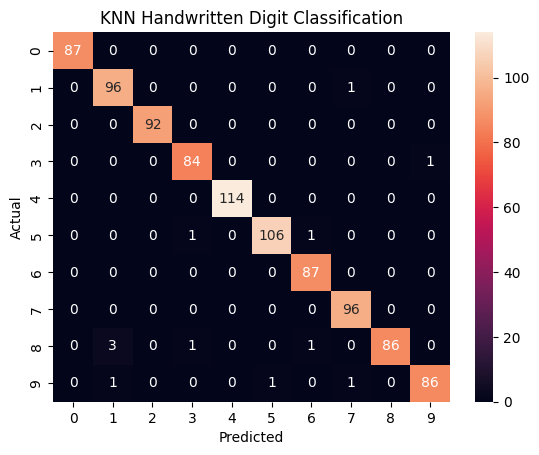

In [13]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

conf_mat = pd.DataFrame(
    confusion_matrix(testLabels, y_pred)
)

sn.heatmap(conf_mat, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Handwritten Digit Classification')

plt.show()

In [14]:
file_name = 'testDigits/0_0.txt'

new_digit = img2vector(file_name)

prediction = model.predict(new_digit)

print("Predicted digit:", prediction[0])

Predicted digit: 0


In [15]:
file_name = 'testDigits/5_0.txt'

new_digit = img2vector(file_name)

prediction = model.predict(new_digit)

print("Predicted digit:", prediction[0])

Predicted digit: 5
